<a href="https://www.kaggle.com/code/avikdas567/predicting-irrigation-need?scriptVersionId=308258252" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

CV Progress:   0%|          | 0/2 [00:00<?, ?it/s]


Fold 1/2
0:	learn: 0.9917125	test: 0.9917182	best: 0.9917182 (0)	total: 1.38s	remaining: 6m 53s
150:	learn: 0.0629810	test: 0.0639728	best: 0.0639728 (150)	total: 2m 40s	remaining: 2m 38s
299:	learn: 0.0603118	test: 0.0619109	best: 0.0619109 (299)	total: 5m 16s	remaining: 0us

bestTest = 0.06191089113
bestIteration = 299



CV Progress:  50%|█████     | 1/2 [05:20<05:20, 320.60s/it]


Fold 2/2
0:	learn: 0.9918329	test: 0.9917874	best: 0.9917874 (0)	total: 1.3s	remaining: 6m 29s
150:	learn: 0.0649884	test: 0.0647585	best: 0.0647585 (150)	total: 2m 39s	remaining: 2m 37s
299:	learn: 0.0626383	test: 0.0628511	best: 0.0628511 (299)	total: 5m 8s	remaining: 0us

bestTest = 0.06285107558
bestIteration = 299



CV Progress: 100%|██████████| 2/2 [10:33<00:00, 316.80s/it]


Balanced Accuracy: 0.96032

'submission.csv' created.


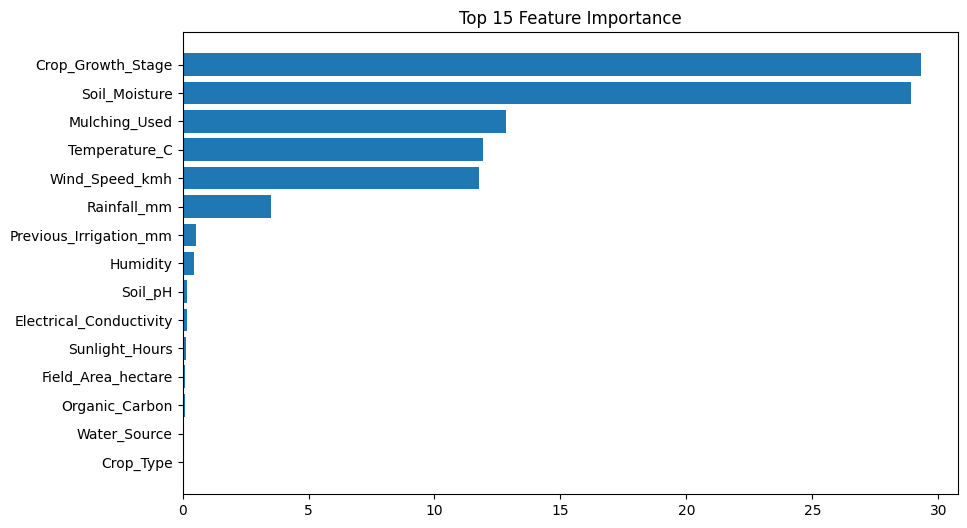

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score

from catboost import CatBoostClassifier
from tqdm import tqdm

# LOAD DATA

train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')

# TARGET & ID

TARGET = "Irrigation_Need"
ID = "id"

# PREPROCESSING

X = train.drop(columns=[TARGET, ID])
y = train[TARGET]
X_test = test.drop(columns=[ID])

le = LabelEncoder()
y_encoded = le.fit_transform(y)

cat_cols = X.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:
    X[col] = X[col].astype(str)
    X_test[col] = X_test[col].astype(str)

# STRATIFIED K-FOLD

N_SPLITS = 2
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_preds = np.zeros((len(X), len(le.classes_)))
test_preds = np.zeros((len(X_test), len(le.classes_)))

# MODEL TRAINING

for fold, (train_idx, val_idx) in enumerate(
    tqdm(skf.split(X, y_encoded), total=N_SPLITS, desc="CV Progress")
):
    print(f"\nFold {fold+1}/{N_SPLITS}")
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]
    
    model = CatBoostClassifier(
        iterations=300,
        learning_rate=0.06,
        depth=5,
        l2_leaf_reg=3,
        loss_function='MultiClass',
        eval_metric='MultiClass',
        random_seed=42,
        verbose=150,
        early_stopping_rounds=30,
        thread_count=-1
    )
    
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_cols,
        use_best_model=True,
        plot=False
    )
    
    oof_preds[val_idx] = model.predict_proba(X_val)
    test_preds += model.predict_proba(X_test) / N_SPLITS

# EVALUATION

oof_labels = np.argmax(oof_preds, axis=1)
score = balanced_accuracy_score(y_encoded, oof_labels)

print(f"Balanced Accuracy: {score:.5f}")

# SUBMISSION

test_labels = np.argmax(test_preds, axis=1)
test_labels = le.inverse_transform(test_labels)

submission = pd.DataFrame({
    "id": test[ID],
    "Irrigation_Need": test_labels
})

submission.to_csv("submission.csv", index=False)

print("\n'submission.csv' created.")

# FEATURE IMPORTANCE

import matplotlib.pyplot as plt

feat_imp = model.get_feature_importance()
feat_names = X.columns

imp_df = pd.DataFrame({
    "feature": feat_names,
    "importance": feat_imp
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(imp_df["feature"][:15][::-1], imp_df["importance"][:15][::-1])
plt.title("Top 15 Feature Importance")
plt.show()